# Localization-only comparison: Baseline vs. BQR-DETR

This notebook evaluates box geometry separately from classification. For every validation image, it uses **all 900 DINO query boxes**, ignores class logits/labels/confidence scores, and pairs boxes to non-difficult GT boxes using Hungarian matching with `5 × L1 + 2 × (1 − GIoU)`.

The model never receives GT during inference. GT boxes are used only after inference to construct evaluation pairs. This is a localization-oracle diagnostic, not a replacement for standard AP.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gt_guided_dino.api import evaluate_localization_only

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
BASELINE_CHECKPOINT = PROJECT_ROOT / 'artifacts' / 'baseline' / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'
BQR_CHECKPOINT = PROJECT_ROOT / 'artifacts' / 'gt_guided_aux' / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'

# The first run evaluates the complete VOC2007 validation split for each checkpoint.
# Results are cached as artifacts/<method>/seed_<seed>/localization_only.json.
RUN_IF_MISSING = True
FORCE_RERUN = False
PRECISION = 'fp16'  # Use 'fp32' when CUDA is unavailable.

for name, checkpoint in {'Baseline': BASELINE_CHECKPOINT, 'BQR-DETR': BQR_CHECKPOINT}.items():
    if not checkpoint.is_file():
        raise FileNotFoundError(f'{name} checkpoint not found: {checkpoint}')
    print(f'{name}: {checkpoint}')

Baseline: D:\BQR_DETR\artifacts\baseline\seed_42\checkpoints\latest.pt
BQR-DETR: D:\BQR_DETR\artifacts\gt_guided_aux\seed_42\checkpoints\latest.pt


In [3]:
def load_or_evaluate(checkpoint: Path) -> dict:
    result_path = checkpoint.parent.parent / 'localization_only.json'
    if result_path.is_file() and not FORCE_RERUN:
        return json.loads(result_path.read_text(encoding='utf-8'))
    if not RUN_IF_MISSING:
        raise FileNotFoundError(f'Missing {result_path}; set RUN_IF_MISSING = True to calculate it.')
    return evaluate_localization_only(
        checkpoint,
        data_root=PROJECT_ROOT / 'VOC2007',
        precision=PRECISION,
    )

baseline = load_or_evaluate(BASELINE_CHECKPOINT)
bqr = load_or_evaluate(BQR_CHECKPOINT)
print(f"Baseline: {baseline['matched_boxes']} matched GT boxes across {baseline['images']} images ({baseline['seconds']:.1f}s)")
print(f"BQR-DETR: {bqr['matched_boxes']} matched GT boxes across {bqr['images']} images ({bqr['seconds']:.1f}s)")

Baseline: 6307 matched GT boxes across 2510 images (464.3s)
BQR-DETR: 6307 matched GT boxes across 2510 images (452.4s)


In [4]:
METRICS = (
    ('Mean Matched IoU', 'mean_matched_iou', 'higher'),
    ('Median Matched IoU', 'median_matched_iou', 'higher'),
    ('Mean Matched GIoU', 'mean_matched_giou', 'higher'),
    ('BBox L1 Error', 'bbox_l1_error', 'lower'),
    ('Center Error (normalized L2)', 'center_error', 'lower'),
    ('Width/Height Error', 'width_height_error', 'lower'),
    ('Matched IoU ≥ 0.50', 'matched_iou50', 'higher'),
    ('Matched IoU ≥ 0.75', 'matched_iou75', 'higher'),
)

lines = ['| Metric | Baseline | BQR-DETR | Raw delta | Better? |', '|---|---:|---:|---:|:---:|']
for label, key, direction in METRICS:
    base, ours = baseline[key], bqr[key]
    is_better = ours > base if direction == 'higher' else ours < base
    lines.append(f'| {label} | {base:.4f} | {ours:.4f} | {ours - base:+.4f} | {"Yes" if is_better else "No"} |')
display(Markdown('\n'.join(lines)))
display(Markdown(
    f"**Matching protocol:** `{baseline['matching_cost']}`. Classification logits, labels and scores are unused."
))

| Metric | Baseline | BQR-DETR | Raw delta | Better? |
|---|---:|---:|---:|:---:|
| Mean Matched IoU | 0.8525 | 0.8524 | -0.0001 | No |
| Median Matched IoU | 0.8997 | 0.8969 | -0.0028 | No |
| Mean Matched GIoU | 0.8479 | 0.8479 | +0.0000 | Yes |
| BBox L1 Error | 0.0123 | 0.0120 | -0.0002 | Yes |
| Center Error (normalized L2) | 0.0155 | 0.0151 | -0.0004 | Yes |
| Width/Height Error | 0.0151 | 0.0149 | -0.0002 | Yes |
| Matched IoU ≥ 0.50 | 0.9659 | 0.9661 | +0.0002 | Yes |
| Matched IoU ≥ 0.75 | 0.8370 | 0.8424 | +0.0054 | Yes |

**Matching protocol:** `5.0 * L1(cx,cy,w,h) + 2.0 * (1 - GIoU)`. Classification logits, labels and scores are unused.

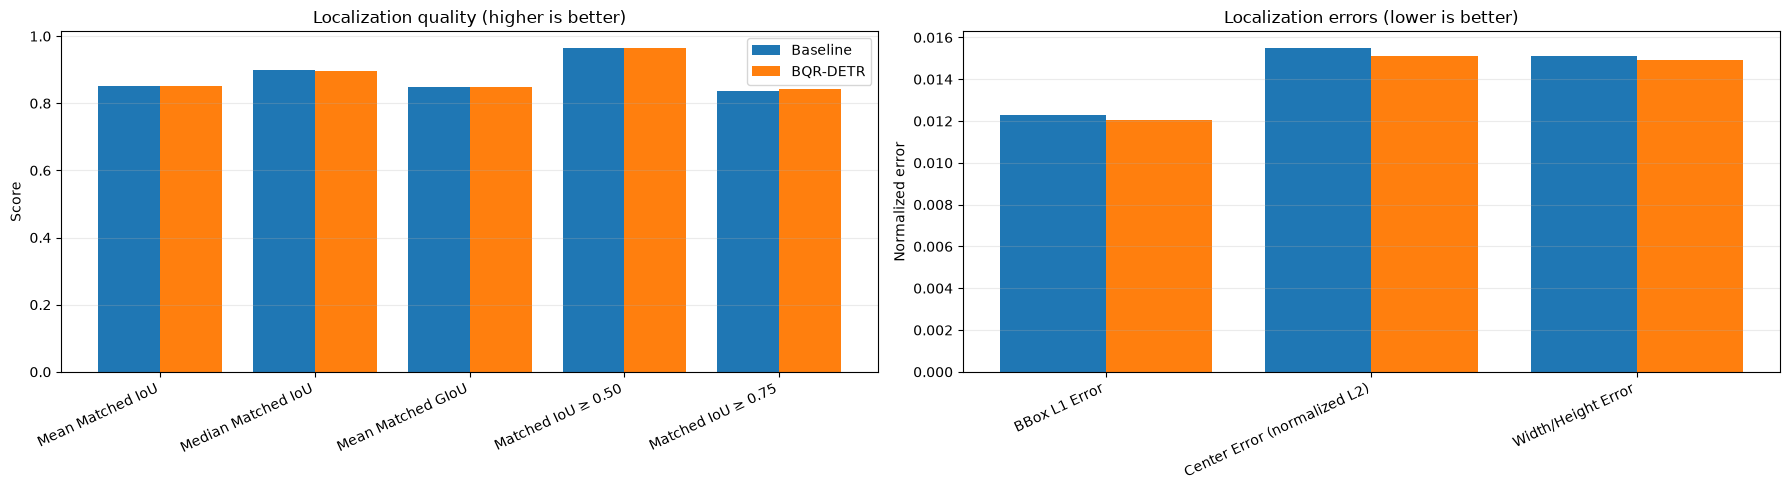

In [5]:
def paired_bar(axis, selected, title, ylabel):
    labels = [label for label, _, _ in selected]
    keys = [key for _, key, _ in selected]
    positions = np.arange(len(keys))
    axis.bar(positions - 0.2, [baseline[key] for key in keys], 0.4, label='Baseline')
    axis.bar(positions + 0.2, [bqr[key] for key in keys], 0.4, label='BQR-DETR')
    axis.set_xticks(positions, labels, rotation=25, ha='right')
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(axis='y', alpha=0.25)

quality = METRICS[:3] + METRICS[6:]
errors = METRICS[3:6]
figure, axes = plt.subplots(1, 2, figsize=(18, 5))
paired_bar(axes[0], quality, 'Localization quality (higher is better)', 'Score')
paired_bar(axes[1], errors, 'Localization errors (lower is better)', 'Normalized error')
axes[0].legend()
figure.tight_layout()

loss_bbox: mean change=-6.52%, final change=-8.00%
loss_giou: mean change=-4.35%, final change=-5.95%


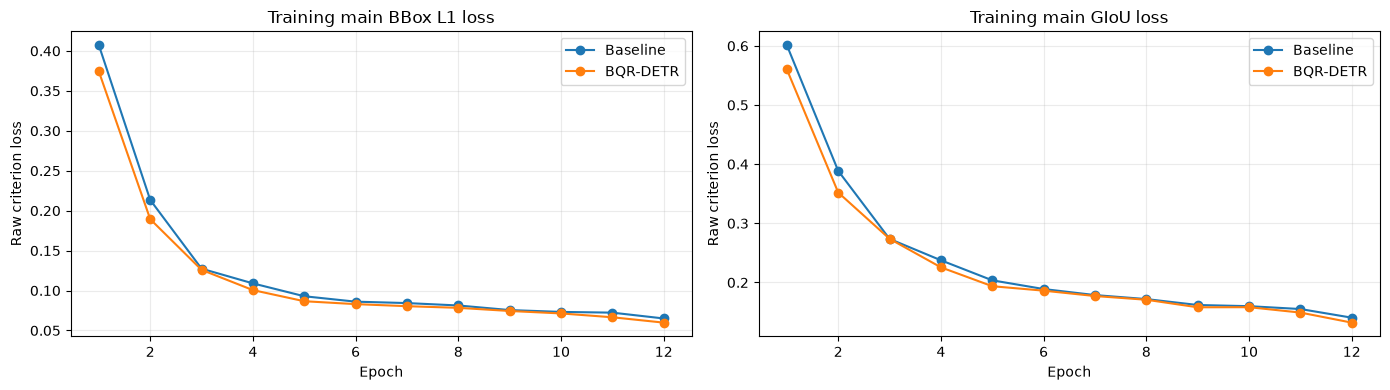

In [6]:
def read_history(checkpoint: Path):
    path = checkpoint.parent.parent / 'history.csv'
    with path.open(encoding='utf-8', newline='') as handle:
        return [{key: float(value) for key, value in row.items() if value not in ('', None)} for row in csv.DictReader(handle)]

baseline_history = read_history(BASELINE_CHECKPOINT)
bqr_history = read_history(BQR_CHECKPOINT)
figure, axes = plt.subplots(1, 2, figsize=(14, 4))
for axis, key, title in (
    (axes[0], 'loss_bbox', 'Training main BBox L1 loss'),
    (axes[1], 'loss_giou', 'Training main GIoU loss'),
):
    axis.plot([row['epoch'] for row in baseline_history], [row[key] for row in baseline_history], marker='o', label='Baseline')
    axis.plot([row['epoch'] for row in bqr_history], [row[key] for row in bqr_history], marker='o', label='BQR-DETR')
    axis.set(title=title, xlabel='Epoch', ylabel='Raw criterion loss')
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()

for key in ('loss_bbox', 'loss_giou'):
    base_values = np.array([row[key] for row in baseline_history])
    bqr_values = np.array([row[key] for row in bqr_history])
    print(f'{key}: mean change={(bqr_values.mean() / base_values.mean() - 1) * 100:+.2f}%, final change={(bqr_values[-1] / base_values[-1] - 1) * 100:+.2f}%')

## Reading the result

A localization-refinement claim is supported when BQR-DETR improves mean/median IoU and GIoU, reduces all three errors, and preferably improves the matched-IoU≥0.75 fraction. AP75 from `03_compare.ipynb` should move in the same direction.

Do not use a lower training regression loss alone as proof: it is measured on the training subset and includes the effect of GT-guided supervision. The validation metrics above are the required out-of-sample check.

## Localization comparison including BQR-DN V2

The following cells add the V2 checkpoint to the same all-query, class-score-free Hungarian localization protocol.

In [ ]:
BQR_DN_V2_CHECKPOINT = PROJECT_ROOT / 'artifacts' / 'bqr_dn_v2' / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'
if not BQR_DN_V2_CHECKPOINT.is_file():
    raise FileNotFoundError(f'BQR-DN V2 checkpoint not found: {BQR_DN_V2_CHECKPOINT}')
bqr_dn_v2 = load_or_evaluate(BQR_DN_V2_CHECKPOINT)
THREE_LOCALIZATION_RUNS = {
    'Baseline': baseline,
    'GT-guided AUX V1': bqr,
    'BQR-DN V2': bqr_dn_v2,
}
print(f"BQR-DN V2: {bqr_dn_v2['matched_boxes']} matched boxes, {bqr_dn_v2['seconds']:.1f}s")

In [ ]:
header = '| Metric | Baseline | AUX V1 | BQR-DN V2 | V2 - Baseline | V2 better? |\n|---|---:|---:|---:|---:|:---:|'
rows = []
for label, key, direction in METRICS:
    base = baseline[key]
    v1 = bqr[key]
    v2 = bqr_dn_v2[key]
    better = v2 > base if direction == 'higher' else v2 < base
    rows.append(f'| {label} | {base:.4f} | {v1:.4f} | {v2:.4f} | {v2 - base:+.4f} | {"Yes" if better else "No"} |')
display(Markdown('\n'.join([header, *rows])))

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(19, 5))
for axis, selected, title, ylabel in (
    (axes[0], METRICS[:3] + METRICS[6:], 'Localization quality (higher is better)', 'Score'),
    (axes[1], METRICS[3:6], 'Localization errors (lower is better)', 'Normalized error'),
):
    labels = [label for label, _, _ in selected]
    keys = [key for _, key, _ in selected]
    positions = np.arange(len(keys))
    width = 0.24
    for index, (name, result) in enumerate(THREE_LOCALIZATION_RUNS.items()):
        axis.bar(positions + (index - 1) * width, [result[key] for key in keys], width, label=name)
    axis.set_xticks(positions, labels, rotation=25, ha='right')
    axis.set(title=title, ylabel=ylabel)
    axis.grid(axis='y', alpha=0.25)
axes[0].legend(fontsize=9)
figure.tight_layout()

In [ ]:
THREE_HISTORIES = {
    'Baseline': read_history(BASELINE_CHECKPOINT),
    'GT-guided AUX V1': read_history(BQR_CHECKPOINT),
    'BQR-DN V2': read_history(BQR_DN_V2_CHECKPOINT),
}
colors = {'Baseline': 'tab:blue', 'GT-guided AUX V1': 'tab:orange', 'BQR-DN V2': 'tab:green'}
figure, axes = plt.subplots(1, 2, figsize=(14, 4))
for axis, key, title in (
    (axes[0], 'loss_bbox', 'Training main BBox L1 loss'),
    (axes[1], 'loss_giou', 'Training main GIoU loss'),
):
    for name, history in THREE_HISTORIES.items():
        axis.plot([row['epoch'] for row in history], [row[key] for row in history], marker='o', label=name, color=colors[name])
    axis.set(title=title, xlabel='Epoch', ylabel='Raw criterion loss')
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()